In [14]:
!nvidia-smi

Tue Sep  1 09:34:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P0             29W /   70W |     247MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
from ultralytics import RTDETR

transformer_model = RTDETR("rtdetr-l.pt")

print("RT-DETR loaded!")

RT-DETR loaded!


In [16]:
results_transformer = transformer_model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    device=0
)


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /content/bus.jpg: 640x640 4 persons, 1 bus, 1 traffic light, 1 fire hydrant, 2 ties, 70.0ms
Speed: 3.6ms preprocess, 70.0ms inference, 0.9ms postprocess per image at shape (1, 3, 640, 640)


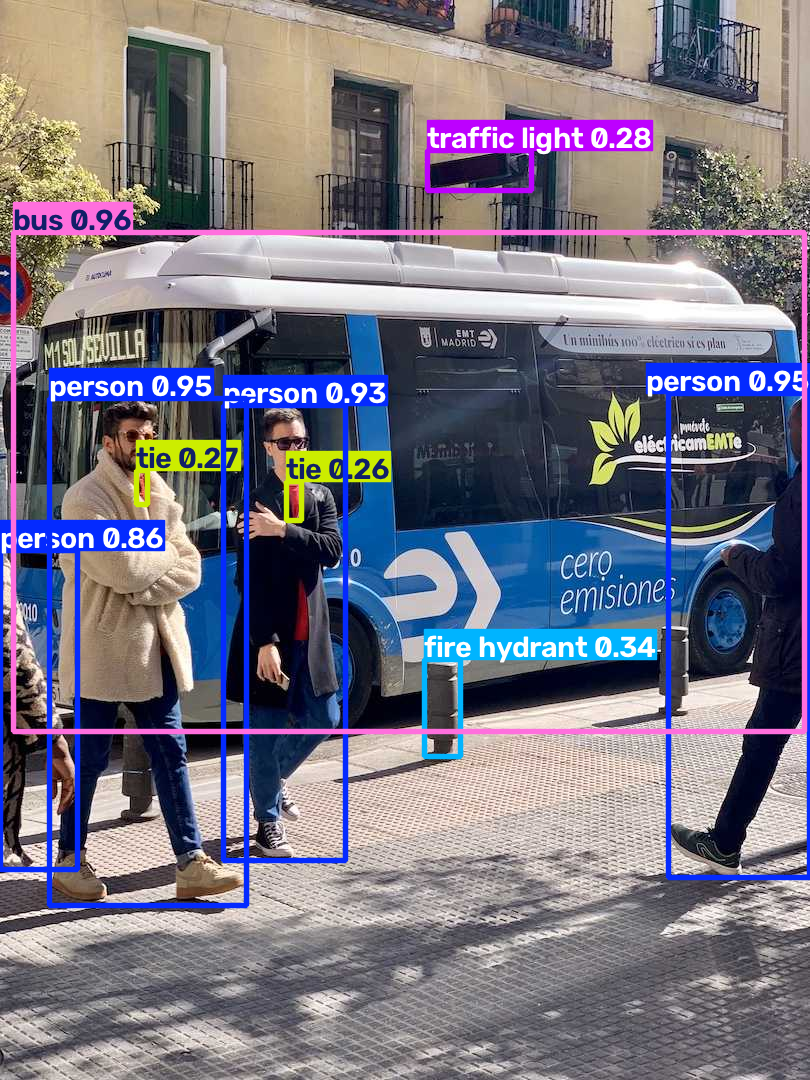

In [17]:
results_transformer[0].show()

In [18]:
import time
import torch

image = "https://ultralytics.com/images/bus.jpg"

# Warm up
for _ in range(10):
    transformer_model.predict(
        source=image,
        device=0,
        verbose=False
    )

torch.cuda.synchronize()

# Benchmark
start = time.time()

for _ in range(50):
    transformer_model.predict(
        source=image,
        device=0,
        verbose=False
    )

torch.cuda.synchronize()

end = time.time()

total_time = end - start
avg_time = total_time / 50
fps = 1 / avg_time

print(f"Total time: {total_time:.2f} seconds")
print(f"Average time: {avg_time*1000:.2f} ms")
print(f"Approximate FPS: {fps:.2f}")

Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
Found https://ultralytics.com/images/bus

In [19]:
print("YOLO11n parameters:", sum(p.numel() for p in model.model.parameters()))
print("RT-DETR-L parameters:", sum(p.numel() for p in transformer_model.model.parameters()))

YOLO11n parameters: 2616248
RT-DETR-L parameters: 32148140


In [20]:
import os

print("YOLO11n file size:",
      round(os.path.getsize("yolo11n.pt") / (1024**2), 2), "MB")

print("RT-DETR-L file size:",
      round(os.path.getsize("rtdetr-l.pt") / (1024**2), 2), "MB")

YOLO11n file size: 5.35 MB
RT-DETR-L file size: 63.43 MB


In [21]:
print("YOLO11n model information:")
model.info()

print("\nRT-DETR-L model information:")
transformer_model.info()

YOLO11n model information:
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

RT-DETR-L model information:
rt-detr-l summary: 294 layers, 32,148,140 parameters, 0 gradients, 105.7 GFLOPs


(294, 32148140, 0, 105.68456)